# 07 · Bagging, Random Forests (and a short note on Boosting)

Notebook 06 ended with the main weakness of trees: **high variance**. Ensembles fix it by combining many trees.

- **Bagging / random forests**: train many deep (low-bias, high-variance) trees **independently** on perturbed data and **average** them → variance goes down.
- **Boosting**: train many shallow (high-bias, low-variance) trees **sequentially**, each correcting the previous ones → bias goes down.

**Contents**

1. Why averaging reduces variance (proof)
2. The bootstrap and out-of-bag examples
3. Bagging
4. Random forests: decorrelating the trees
5. Hyperparameters and feature importance
6. Boosting in brief: AdaBoost and gradient boosting
7. Bagging vs. boosting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. Why averaging reduces variance

Let $h_1(\mathbf{x}),\dots,h_B(\mathbf{x})$ be the predictions of $B$ models at a fixed point, each with variance $\sigma^2$ and pairwise correlation $\rho$. Their average $\bar h = \frac1B\sum_b h_b$ has

$$
\boxed{\mathrm{Var}(\bar h) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2}
$$

*Proof.* $\mathrm{Var}\big(\sum_b h_b\big) = \sum_b\mathrm{Var}(h_b) + \sum_{b\ne b'}\mathrm{Cov}(h_b,h_{b'}) = B\sigma^2 + B(B-1)\rho\sigma^2$. Divide by $B^2$: $\frac{\sigma^2}{B} + \frac{B-1}{B}\rho\sigma^2 = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$. $\blacksquare$

Consequences:
- The **bias** doesn't change (the mean of identically distributed models has the same expectation), so average **low-bias** models: deep trees.
- As $B\to\infty$ the second term vanishes, so **more trees never hurt** (they just cost compute), and the error levels off.
- The floor is $\rho\sigma^2$: to go lower, the models must be **less correlated**. That is exactly what random forests add over bagging.

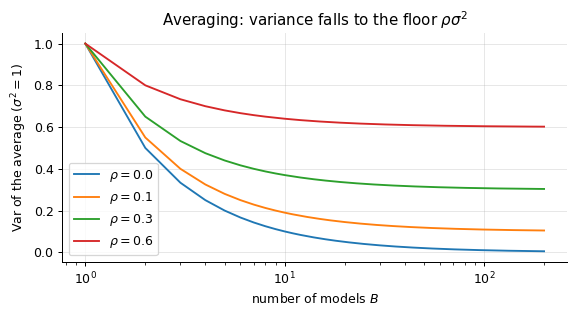

In [2]:
sigma2 = 1.0; B = np.arange(1, 201)
plt.figure(figsize=(6.5, 3.6))
for rho in [0.0, 0.1, 0.3, 0.6]:
    plt.plot(B, rho * sigma2 + (1 - rho) * sigma2 / B, label=rf"$\rho={rho}$")
plt.xscale("log"); plt.xlabel("number of models $B$"); plt.ylabel(r"Var of the average ($\sigma^2=1$)")
plt.legend(); plt.title(r"Averaging: variance falls to the floor $\rho\sigma^2$"); plt.tight_layout(); plt.show()

## 2. The bootstrap and out-of-bag examples

We only have one training set. To get "different" training sets, draw $m$ examples **with replacement** from the $m$ we have: a **bootstrap sample**. Some examples appear several times, others not at all.

**Probability that a given example is left out:** each draw misses it with probability $1-\frac1m$, and there are $m$ independent draws:

$$
P(\text{not in sample}) = \Big(1-\frac1m\Big)^m \xrightarrow{m\to\infty} e^{-1}\approx 0.368 .
$$

(Using $\log(1-\frac1m)^m = m\log(1-\frac1m) \approx m\cdot(-\frac1m) = -1$.) So each bootstrap sample contains about **63.2 %** of the distinct examples. The remaining ~36.8 % are that tree's **out-of-bag (OOB)** examples.

**OOB error**: predict each training example using only the trees that did *not* see it, and average the errors. It is a nearly free estimate of the test error, similar to cross-validation, without a separate validation set.

In [3]:
for m in [10, 100, 1000, 100000]:
    frac_in = np.mean([len(np.unique(rng.integers(0, m, m))) / m for _ in range(200)])
    print(f"m={m:6d}: fraction of distinct examples in a bootstrap sample = {frac_in:.3f}   (theory 1-(1-1/m)^m = {1-(1-1/m)**m:.3f})")

m=    10: fraction of distinct examples in a bootstrap sample = 0.657   (theory 1-(1-1/m)^m = 0.651)
m=   100: fraction of distinct examples in a bootstrap sample = 0.637   (theory 1-(1-1/m)^m = 0.634)
m=  1000: fraction of distinct examples in a bootstrap sample = 0.633   (theory 1-(1-1/m)^m = 0.632)


m=100000: fraction of distinct examples in a bootstrap sample = 0.632   (theory 1-(1-1/m)^m = 0.632)


## 3. Bagging (Bootstrap AGGregatING)

```
for b = 1..B:
    draw a bootstrap sample D_b of size m
    fit a deep tree h_b on D_b            (no pruning: low bias, high variance)
predict:  regression      h(x) = (1/B) Σ_b h_b(x)
          classification  average the class probabilities (or majority vote)
```

Bagging works for any unstable model, but trees are the classic case. Linear regression, being stable, gains almost nothing.

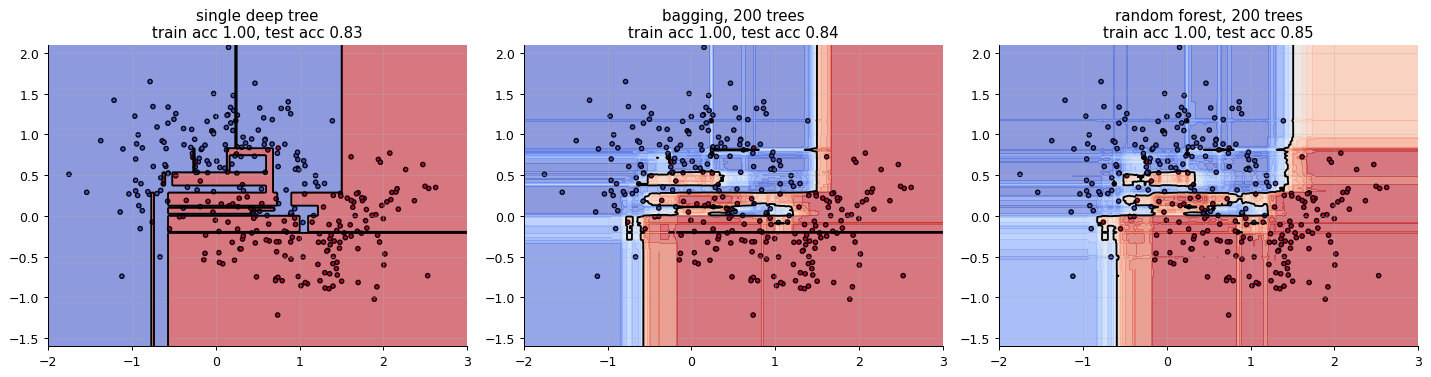

In [4]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

Xm, ym = make_moons(n_samples=500, noise=0.35, random_state=1)
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.4, random_state=0)
g1, g2 = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.6, 2.1, 300)); G = np.c_[g1.ravel(), g2.ravel()]

models = [("single deep tree", DecisionTreeClassifier(random_state=0)),
          ("bagging, 200 trees", BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=0)),
          ("random forest, 200 trees", RandomForestClassifier(n_estimators=200, random_state=0))]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, (name, mdl) in zip(axes, models):
    mdl.fit(Xtr, ytr); P = mdl.predict_proba(G)[:, 1].reshape(g1.shape)
    ax.contourf(g1, g2, P, levels=20, cmap="coolwarm", alpha=0.6); ax.contour(g1, g2, P, levels=[0.5], colors="k")
    ax.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(f"{name}\ntrain acc {mdl.score(Xtr, ytr):.2f}, test acc {mdl.score(Xte, yte):.2f}")
plt.tight_layout(); plt.show()

The single tree carves out tiny regions around individual noisy points. The ensembles average those accidents away, giving smoother boundaries and graded probabilities.

## 4. Random forests: decorrelating the trees

Bagged trees are still strongly **correlated**: if one feature is very predictive, almost every tree puts it at the top, so the trees look alike and $\rho$ stays high (section 1).

**Random forest** (Breiman, 2001) = bagging + one extra source of randomness: **at each split, only a random subset of `max_features` features is considered** (a new subset at every node).

- Typical values: $\sqrt{n}$ for classification, $n/3$ (or all, in scikit-learn's current default) for regression. `max_features = n` is plain bagging.
- Smaller `max_features` → less correlated trees (lower $\rho$) but each tree is a bit weaker (higher $\sigma^2$/bias). The best value is found by CV/OOB, but the defaults are usually good.
- Each tree is grown deep and not pruned. Trees are independent, so training parallelises trivially (`n_jobs=-1`).

The experiment below uses a dataset with a few strong features and many weak ones, and measures the correlation between trees' predictions and the test error as `max_features` varies.

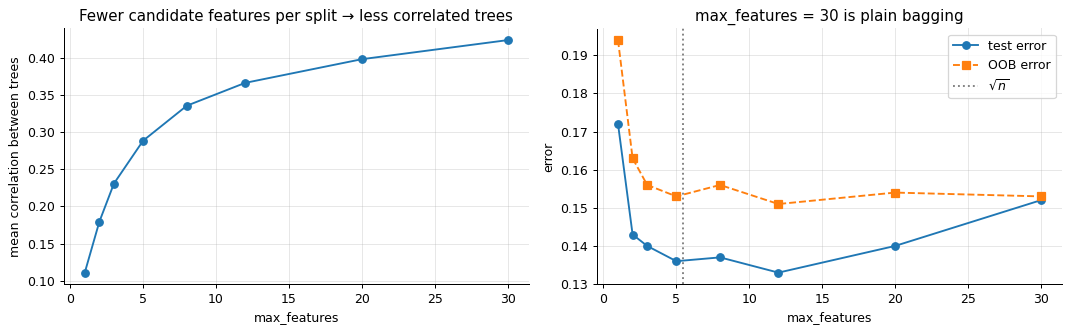

In [5]:
from sklearn.datasets import make_classification
Xc, yc = make_classification(n_samples=2000, n_features=30, n_informative=8, n_redundant=6,
                             class_sep=0.8, flip_y=0.05, random_state=2)
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xc, yc, test_size=0.5, random_state=0)

mf_values = [1, 2, 3, 5, 8, 12, 20, 30]
corr, err, oob = [], [], []
for mf in mf_values:
    rf = RandomForestClassifier(n_estimators=300, max_features=mf, oob_score=True, random_state=0, n_jobs=-1).fit(Xtr2, ytr2)
    P = np.array([t.predict_proba(Xte2)[:, 1] for t in rf.estimators_])      # (trees x test points)
    C = np.corrcoef(P); corr.append(C[np.triu_indices_from(C, 1)].mean())
    err.append(1 - rf.score(Xte2, yte2)); oob.append(1 - rf.oob_score_)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(mf_values, corr, "o-"); axes[0].set_xlabel("max_features"); axes[0].set_ylabel("mean correlation between trees")
axes[0].set_title("Fewer candidate features per split → less correlated trees")
axes[1].plot(mf_values, err, "o-", label="test error"); axes[1].plot(mf_values, oob, "s--", label="OOB error")
axes[1].axvline(np.sqrt(30), color="gray", ls=":", label=r"$\sqrt{n}$"); axes[1].set_xlabel("max_features")
axes[1].set_ylabel("error"); axes[1].legend(); axes[1].set_title("max_features = 30 is plain bagging")
plt.tight_layout(); plt.show()

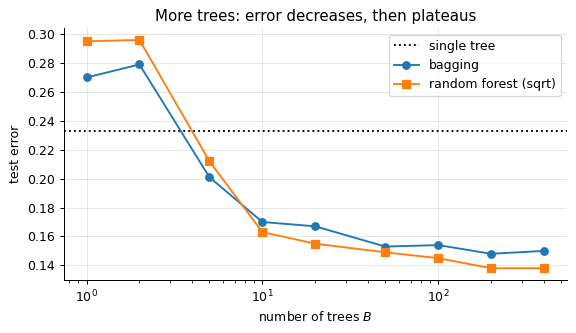

In [6]:
# Error vs. number of trees: it levels off, it does not go back up
n_list = [1, 2, 5, 10, 20, 50, 100, 200, 400]
single = 1 - DecisionTreeClassifier(random_state=0).fit(Xtr2, ytr2).score(Xte2, yte2)
e_bag = [1 - RandomForestClassifier(n_estimators=k, max_features=None, random_state=0, n_jobs=-1).fit(Xtr2, ytr2).score(Xte2, yte2) for k in n_list]
e_rf = [1 - RandomForestClassifier(n_estimators=k, max_features="sqrt", random_state=0, n_jobs=-1).fit(Xtr2, ytr2).score(Xte2, yte2) for k in n_list]
plt.figure(figsize=(6.5, 3.8))
plt.axhline(single, color="k", ls=":", label="single tree")
plt.plot(n_list, e_bag, "o-", label="bagging"); plt.plot(n_list, e_rf, "s-", label="random forest (sqrt)")
plt.xscale("log"); plt.xlabel("number of trees $B$"); plt.ylabel("test error"); plt.legend(); plt.title("More trees: error decreases, then plateaus")
plt.tight_layout(); plt.show()

## 5. Hyperparameters and feature importance

| Hyperparameter | Effect | Typical choice |
|---|---|---|
| `n_estimators` ($B$) | more = lower variance, never overfits by itself | a few hundred; stop when OOB error is flat |
| `max_features` | lower = more decorrelation, weaker trees | $\sqrt{n}$ (clf.), tune by OOB/CV |
| `max_depth`, `min_samples_leaf` | per-tree complexity | fully grown, or a small `min_samples_leaf` for noisy data |
| `bootstrap`, `max_samples` | size of each sample | default |

**Feature importance.**
- **MDI** (`feature_importances_`): impurity decrease per feature, averaged over trees (notebook 06). Free, but computed on training data and biased towards continuous / high-cardinality features.
- **Permutation importance**: shuffle one feature in the validation set and measure how much the score drops. Model-agnostic and computed on held-out data, so more trustworthy. With correlated features both methods split the credit among them.

Random forests are strong defaults for tabular data. They need little tuning or preprocessing (no scaling) and are hard to overfit badly. Their costs: less interpretable than a single tree, larger models, and they can't extrapolate beyond the training range.

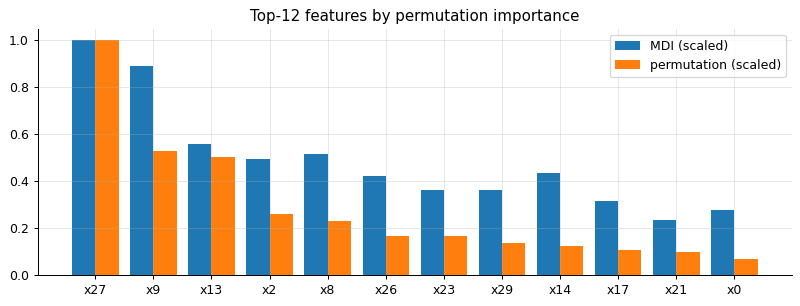

In [7]:
from sklearn.inspection import permutation_importance
rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(Xtr2, ytr2)
perm = permutation_importance(rf, Xte2, yte2, n_repeats=10, random_state=0, n_jobs=-1)
order = np.argsort(perm.importances_mean)[::-1][:12]
fig, ax = plt.subplots(figsize=(9, 3.5)); w = 0.4
ax.bar(np.arange(12) - w / 2, rf.feature_importances_[order] / rf.feature_importances_.max(), w, label="MDI (scaled)")
ax.bar(np.arange(12) + w / 2, perm.importances_mean[order] / perm.importances_mean.max(), w, label="permutation (scaled)")
ax.set_xticks(range(12)); ax.set_xticklabels([f"x{j}" for j in order]); ax.legend(); ax.set_title("Top-12 features by permutation importance")
plt.tight_layout(); plt.show()

## 6. Boosting in brief

Instead of averaging independent strong models, boosting builds an **additive model** of many weak ones (typically shallow trees), each fitted to what the current ensemble still gets wrong:

$$
F_M(\mathbf{x}) = F_0(\mathbf{x}) + \nu\sum_{t=1}^M h_t(\mathbf{x}).
$$

### AdaBoost (classification, $y\in\{-1,+1\}$)

Keep a weight per training example. At each round: fit a weak classifier $h_t$ on the weighted data, compute its weighted error $\varepsilon_t$, give it a vote $\alpha_t = \frac12\log\frac{1-\varepsilon_t}{\varepsilon_t}$, and **increase the weights of the misclassified examples** ($w_i \leftarrow w_i e^{-\alpha_t y^{(i)}h_t(\mathbf{x}^{(i)})}$, then renormalise). Final prediction: $\mathrm{sign}\sum_t\alpha_th_t(\mathbf{x})$. It can be shown to be greedy minimisation of the exponential loss $e^{-yF(\mathbf{x})}$.

### Gradient boosting (any differentiable loss)

View training as **gradient descent in function space**. With loss $\sum_i\ell(y^{(i)}, F(\mathbf{x}^{(i)}))$, at step $t$ compute the **pseudo-residuals**

$$
r^{(i)}_t = -\left.\frac{\partial\,\ell(y^{(i)}, F)}{\partial F}\right|_{F = F_{t-1}(\mathbf{x}^{(i)})},
$$

fit a small regression tree $h_t$ to $\{(\mathbf{x}^{(i)}, r^{(i)}_t)\}$, and update $F_t = F_{t-1} + \nu h_t$.

- **Squared loss** $\ell = \frac12(y-F)^2$: $r = y - F$. The pseudo-residuals are the **ordinary residuals**: each tree fits what is left to explain.
- **Log-loss** with $F$ = log-odds, $p = \sigma(F)$: $r = y - p$ (same derivation as notebook 02).
- $F_0$ is the best constant (mean of $y$, or the log-odds of the base rate).

Key hyperparameters: learning rate $\nu$ (shrinkage, e.g. 0.05–0.1: smaller needs more trees but generalises better), number of trees $M$ (**can overfit**, so choose it by early stopping on a validation set), tree depth (2–6), row/column subsampling. XGBoost, LightGBM and CatBoost are optimised implementations with extra regularisation (penalties on leaf values and number of leaves, second-order gradients). See the XGBoost lab.

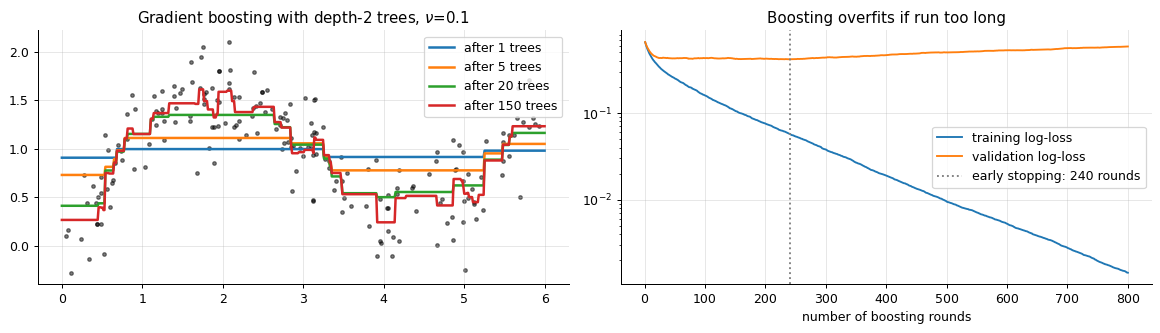

                       random forest: test error 0.136   test log-loss 0.396
   boosting, 240 rounds (early stop): test error 0.143   test log-loss 0.371
                boosting, 800 rounds: test error 0.144   test log-loss 0.494


In [8]:
# Gradient boosting for squared loss, from scratch: each stump fits the current residuals
from sklearn.tree import DecisionTreeRegressor
xr = np.sort(rng.uniform(0, 6, 200)); yr = np.sin(xr) + 0.3 * xr + rng.normal(0, 0.3, 200)
gr = np.linspace(0, 6, 500)
nu, M = 0.1, 150
F = np.full_like(yr, yr.mean()); Fg = np.full_like(gr, yr.mean()); snaps = {}
for t in range(1, M + 1):
    r = yr - F                                            # pseudo-residuals = residuals
    h = DecisionTreeRegressor(max_depth=2, min_samples_leaf=10).fit(xr[:, None], r)
    F += nu * h.predict(xr[:, None]); Fg += nu * h.predict(gr[:, None])
    if t in (1, 5, 20, 150): snaps[t] = Fg.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].scatter(xr, yr, s=8, color="k", alpha=0.5)
for t, f in snaps.items(): axes[0].plot(gr, f, lw=2, label=f"after {t} trees")
axes[0].legend(); axes[0].set_title(rf"Gradient boosting with depth-2 trees, $\nu$={nu}")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss
# hold out a validation set from the training data to choose the number of rounds
Xfit, Xval, yfit, yval = train_test_split(Xtr2, ytr2, test_size=0.25, random_state=0)
gb = GradientBoostingClassifier(n_estimators=800, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=0).fit(Xfit, yfit)
tr_l = [log_loss(yfit, p) for p in gb.staged_predict_proba(Xfit)]
va_l = [log_loss(yval, p) for p in gb.staged_predict_proba(Xval)]
best = int(np.argmin(va_l)) + 1
axes[1].plot(range(1, 801), tr_l, label="training log-loss"); axes[1].plot(range(1, 801), va_l, label="validation log-loss")
axes[1].axvline(best, color="gray", ls=":", label=f"early stopping: {best} rounds")
axes[1].set_xlabel("number of boosting rounds"); axes[1].set_yscale("log"); axes[1].legend()
axes[1].set_title("Boosting overfits if run too long")
plt.tight_layout(); plt.show()

gb_best = GradientBoostingClassifier(n_estimators=best, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=0).fit(Xfit, yfit)
for name, mdl in [("random forest", rf), (f"boosting, {best} rounds (early stop)", gb_best), ("boosting, 800 rounds", gb)]:
    print(f"{name:>36}: test error {1 - mdl.score(Xte2, yte2):.3f}   test log-loss {log_loss(yte2, mdl.predict_proba(Xte2)):.3f}")

Training loss keeps falling towards 0 while validation loss reaches a minimum and then rises. Notice that the **log-loss** degrades much earlier and more clearly than the **error rate**: the extra rounds mostly make the predicted probabilities over-confident. Early stopping on a validation set (`n_iter_no_change` in scikit-learn, `early_stopping_rounds` in XGBoost) picks the number of rounds automatically.

## 7. Bagging vs. boosting

| | Bagging / Random forest | Boosting (AdaBoost, gradient boosting) |
|---|---|---|
| Base learners | deep trees (low bias, high variance) | shallow trees (high bias, low variance) |
| Training | independent, parallel | sequential, each corrects the previous |
| Reduces mainly | variance | bias (and variance, via shrinkage) |
| Combination | plain average / vote | weighted sum $F_0 + \nu\sum h_t$ |
| More trees | never overfits, plateaus | eventually overfits → early stopping |
| Tuning effort | low (good defaults) | higher ($\nu$, $M$, depth, subsampling) |
| Typical accuracy on tabular data | very good with defaults | often the best, after tuning |

## Summary

- Averaging $B$ models with variance $\sigma^2$ and correlation $\rho$ gives variance $\rho\sigma^2 + (1-\rho)\sigma^2/B$.
- Bagging: deep trees on bootstrap samples (~63 % distinct points each), averaged; OOB examples give a free error estimate.
- Random forests also sample `max_features` candidate features at every split, which lowers $\rho$ and usually the error.
- Boosting builds an additive model sequentially; gradient boosting fits each new tree to the negative gradient of the loss (the residuals, for squared loss); tune the learning rate and number of trees with early stopping.